In [1]:
import numpy as np
times_path = r"C:\Users\jreyesva\Downloads\xmp_csv_files\sgmii_xmp_refclk_000004_000001_per_clk1.csv"
periods = np.loadtxt(times_path, delimiter=",", dtype=float).reshape(-1)
crossing_times = np.cumsum(periods)
print(crossing_times.shape)

(123750,)


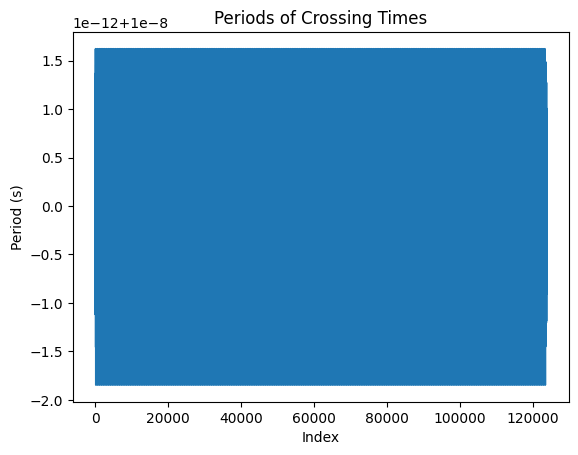

Frequency: 100000013.53772356


In [2]:
import matplotlib.pyplot as plt
periods = np.diff(crossing_times)
plt.plot(periods)
plt.xlabel("Index")
plt.ylabel("Period (s)")
plt.title("Periods of Crossing Times")
plt.show()
print(f"Frequency: {1/np.mean(periods)}")

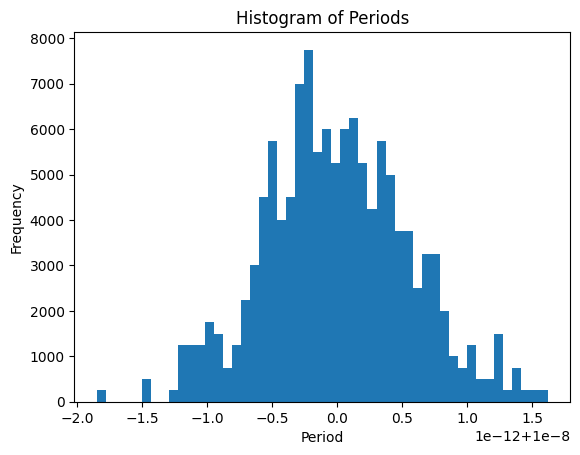

In [3]:
plt.hist(periods, bins=50)
plt.xlabel("Period")
plt.ylabel("Frequency")
plt.title("Histogram of Periods")
plt.show()

In [4]:
edge_index = np.arange(len(crossing_times))
fitted_period, fitted_intercept = np.polyfit(edge_index, crossing_times, 1)
fitted_freq = 1 / fitted_period
print(f"Fitted frequency: {fitted_freq}")

Fitted frequency: 100000013.5212155


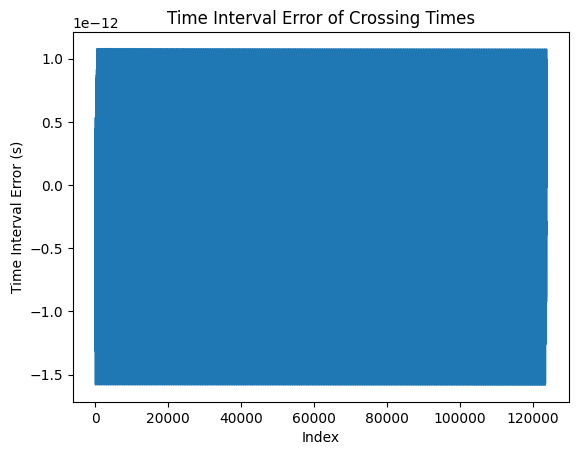

In [5]:
ideal_crossing_times = fitted_intercept + fitted_period * edge_index
tie = crossing_times - ideal_crossing_times
plt.plot(tie)
plt.xlabel("Index")
plt.ylabel("Time Interval Error (s)")
plt.title("Time Interval Error of Crossing Times")
plt.show()

In [6]:
rms_jitter = np.sqrt(np.mean(tie**2))
print(f"RMS Jitter: {rms_jitter*1e15}fs")

RMS Jitter: 457.7139598170492fs


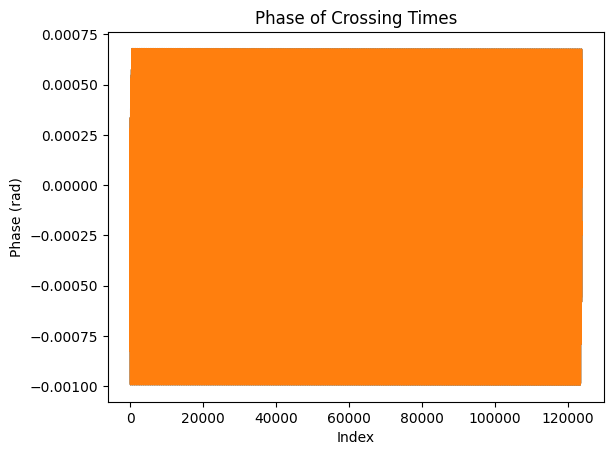

In [7]:
phi = tie * 2 * np.pi * fitted_freq 
plt.plot(phi)
plt.plot(phi - np.mean(phi))
plt.xlabel("Index")
plt.ylabel("Phase (rad)")
plt.title("Phase of Crossing Times")
plt.show()

In [8]:
phi_fft = np.fft.rfft(phi)
freqs = np.fft.rfftfreq(len(phi), d=1/fitted_freq)
psd = (np.abs(phi_fft)**2) / (fitted_freq * len(phi))
if len(psd) % 2 == 0:
    psd[1:-1] *= 2.0
else:
    psd[1:] *= 2.0
l_psd = 10 * np.log10(psd/2)

In [9]:
mask = [-130, -138, -138, -140, -144, -146, -146, -146]
mask_freqs = [10e3, 100e3, 500e3, 3e6, 10e6, 20e6, 100e6, 1e9]
mask_compensation =20*np.log10(fitted_freq/156.25e6)
print(mask_compensation)

-3.87639934588448


C:\temp\ipykernel_16704\3476400796.py:5: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0, max(mask_freqs)])


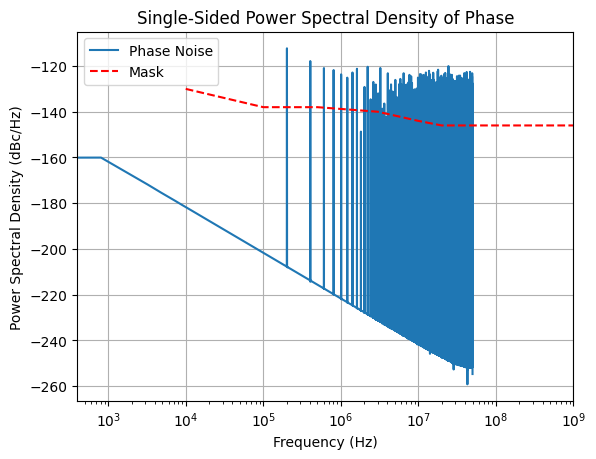

In [10]:
plt.plot(freqs, l_psd, label='Phase Noise')
plt.plot(mask_freqs, mask, 'r--', label='Mask')
plt.xscale('log')
plt.xlabel("Frequency (Hz)")
plt.xlim([0, max(mask_freqs)])
plt.ylabel("Power Spectral Density (dBc/Hz)")
plt.title("Single-Sided Power Spectral Density of Phase")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
integration_range = [10e3, 20e6]
integration_indices = np.logical_and(freqs >= integration_range[0], freqs <= integration_range[1])
integration_psd = l_psd[integration_indices]
integration_freqs = freqs[integration_indices]
s_phi = 2 * 10 ** (integration_psd / 10)
df = integration_freqs[1] - integration_freqs[0]
phi_rms_squared = np.sum(s_phi) * df
phi_rms = np.sqrt(phi_rms_squared)
recovered_rms_jitter = phi_rms / (2 * np.pi * fitted_freq)
print(f"Integrated RMS jitter from {integration_range[0] / 1e3} kHz to {integration_range[1] / 1e6} MHz: {recovered_rms_jitter * 1e15}fs")

Integrated RMS jitter from 10.0 kHz to 20.0 MHz: 343.24587575306fs
